In [1]:
import pandas as pd
import numpy as np

print('Project name: Career AI!')

Project name: Career AI!


In [2]:
import pandas as np

df = pd.read_csv('../data/raw/profiles_test.csv')

df.head()

,profile_id,years_experience,projects_count,certifications_count,skill_python,skill_sql,skill_machine_learning,skill_statistics,skill_pandas,skill_numpy,skill_scikit_learn,skill_pytorch,skill_docker,skill_javascript,career_class
0,P0001,3,4,2,3,0,0,2,1,2,2,2,2,3,Data Engineer
1,P0002,3,7,2,1,0,1,3,3,1,1,1,3,3,Data Engineer
2,P0003,0,3,1,1,0,3,0,0,2,2,2,1,3,QA Automation Engineer
3,P0004,3,7,2,3,2,3,3,0,2,0,2,2,0,DevOps Engineer
4,P0005,1,3,0,3,1,1,1,0,1,0,1,3,3,QA Automation Engineer


In [4]:
df.shape

(120, 15)

In [5]:
df.columns

Index(['profile_id', 'years_experience', 'projects_count',
       'certifications_count', 'skill_python', 'skill_sql',
       'skill_machine_learning', 'skill_statistics', 'skill_pandas',
       'skill_numpy', 'skill_scikit_learn', 'skill_pytorch', 'skill_docker',
       'skill_javascript', 'career_class'],
      dtype='str')

In [6]:
df.isnull().sum()

profile_id                0
years_experience          0
projects_count            0
certifications_count      0
skill_python              0
skill_sql                 0
skill_machine_learning    0
skill_statistics          0
skill_pandas              0
skill_numpy               0
skill_scikit_learn        0
skill_pytorch             0
skill_docker              0
skill_javascript          0
career_class              0
dtype: int64

In [7]:
df['career_class'].value_counts()

career_class
Data Analyst                 14
Data Engineer                13
Full Stack Developer         12
QA Automation Engineer       11
DevOps Engineer              11
Backend Developer            10
Cloud Engineer               10
Cybersecurity Analyst         9
Machine Learning Engineer     9
Frontend Developer            9
Data Scientist                8
AI Engineer                   4
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


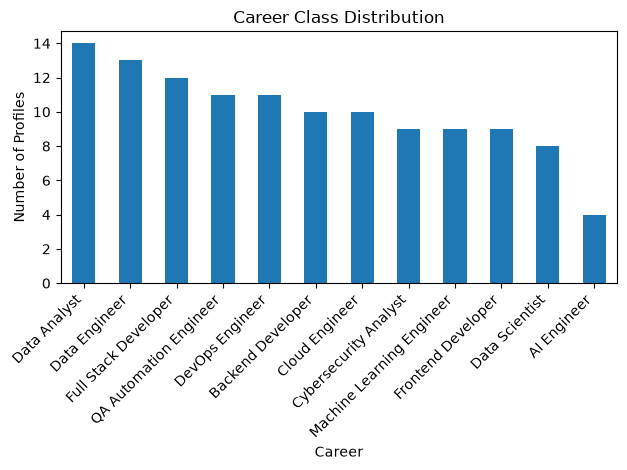

In [8]:
import matplotlib.pyplot as plt

df["career_class"].value_counts().plot(kind="bar")

plt.title("Career Class Distribution")
plt.xlabel("Career")
plt.ylabel("Number of Profiles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
X = df.drop(columns=["profile_id", "career_class"])
y = df["career_class"]

print(X.shape)
print(y.shape)

(120, 13)
(120,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (96, 13)
Testing: (24, 13)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [14]:
y_pred = model.predict(X_test)

print(y_pred)

['Machine Learning Engineer' 'Data Scientist' 'Cloud Engineer'
 'Data Engineer' 'Backend Developer' 'AI Engineer' 'DevOps Engineer'
 'Machine Learning Engineer' 'Data Engineer' 'QA Automation Engineer'
 'Data Engineer' 'Cybersecurity Analyst' 'Data Scientist'
 'DevOps Engineer' 'Cybersecurity Analyst' 'Backend Developer'
 'Frontend Developer' 'Cybersecurity Analyst' 'DevOps Engineer'
 'AI Engineer' 'Cybersecurity Analyst' 'Machine Learning Engineer'
 'Full Stack Developer' 'Cloud Engineer']


In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.125
